# 13 — Dataset ภาพท้องฟ้าสำหรับโมดูล CNN

ข้อมูลมาจาก `python -m src.sky_data --download --index` (รายละเอียด license อยู่ใน `docs/datasets.md`)
- **CCSN:** CC0, 2,543 ภาพจากกล้องธรรมดา แบ่งเป็นเมฆ 11 ชนิด
- **SWIMCAT-ext:** CC BY 4.0, 2,100 patch จากกล้องถ่ายท้องฟ้า 6 คลาส ใช้แทน SWIMCAT ระหว่างรอแบบฟอร์ม
- **SWIMSEG:** ยังรอลิงก์

แต่ละ dataset มี label และ split ของตัวเอง (70/15/15, stratified) ภาพที่ซ้ำหรือเกือบซ้ำถูกบังคับให้อยู่ใน split เดียวกัน **notebook นี้แสดงภาพจาก train split เท่านั้น**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

In [2]:
from PIL import Image

from src import sky_data as sd

tabs = {n: pd.read_csv(sd.SPLIT_DIR / f"{n}_split.csv") for n in ("ccsn", "swimcat_ext")}
for n, t in tabs.items():
    grp = t.groupby("dup_group")["path"].transform("size")
    print(f"{n}: {len(t)} images | near-duplicate groups >1: {t.loc[grp > 1, 'dup_group'].nunique()} "
          f"({int((grp > 1).sum())} images) | label conflicts: {int(t['label_conflict'].sum())} images | "
          f"groups spanning splits: {int((t.groupby('dup_group')['split'].nunique() > 1).sum())}")
    display(sd.split_summary(t))

ccsn: 2543 images | near-duplicate groups >1: 164 (344 images) | label conflicts: 263 images | groups spanning splits: 0


split,train,val,test,All
label,,,,
Ac,153,34,34,221
As,134,24,30,188
Cb,169,38,35,242
Cc,189,42,37,268
Ci,99,21,19,139
Cs,198,46,43,287
Ct,141,30,29,200
Cu,128,28,26,182
Ns,193,44,37,274


swimcat_ext: 2100 images | near-duplicate groups >1: 534 (1470 images) | label conflicts: 0 images | groups spanning splits: 0


split,train,val,test,All
label,,,,
clear_sky,245,53,52,350
patterned_clouds,245,53,52,350
thick_dark_clouds,245,54,51,350
thick_white_clouds,245,53,52,350
thin_white_clouds,245,53,52,350
veil_clouds,247,51,52,350
All,1472,317,311,2100


## 1. ตัวอย่างภาพต่อคลาส (train split)

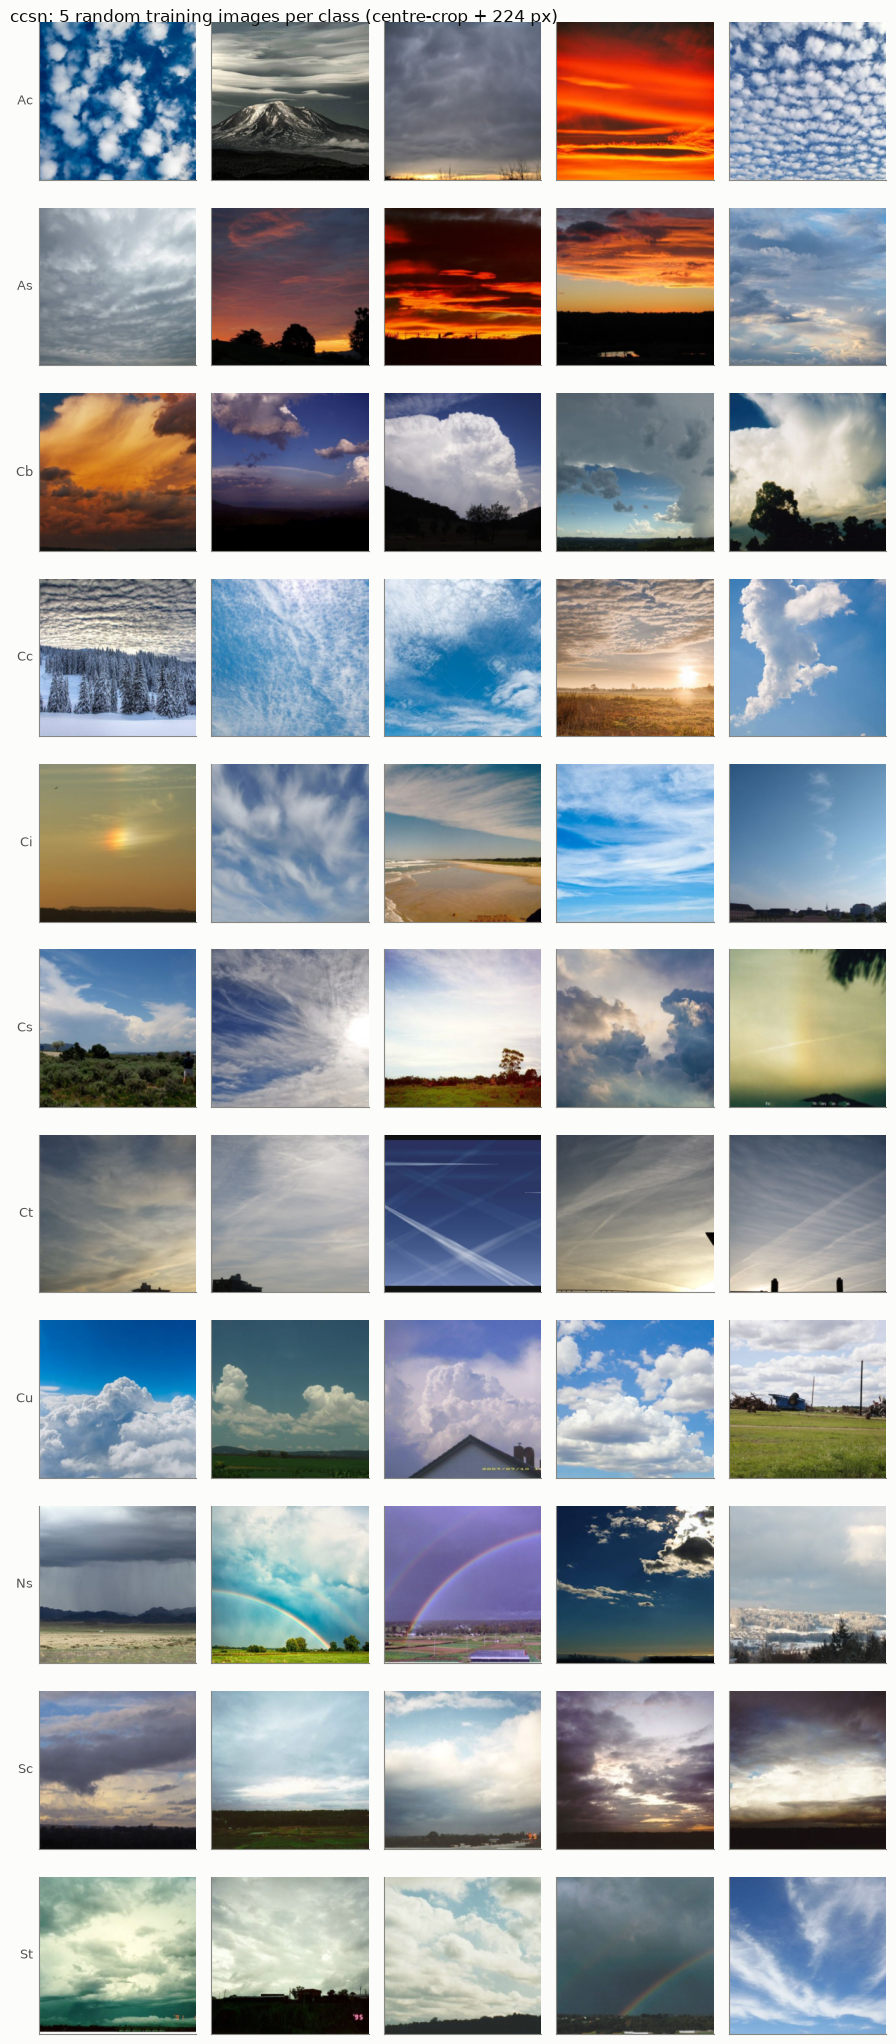

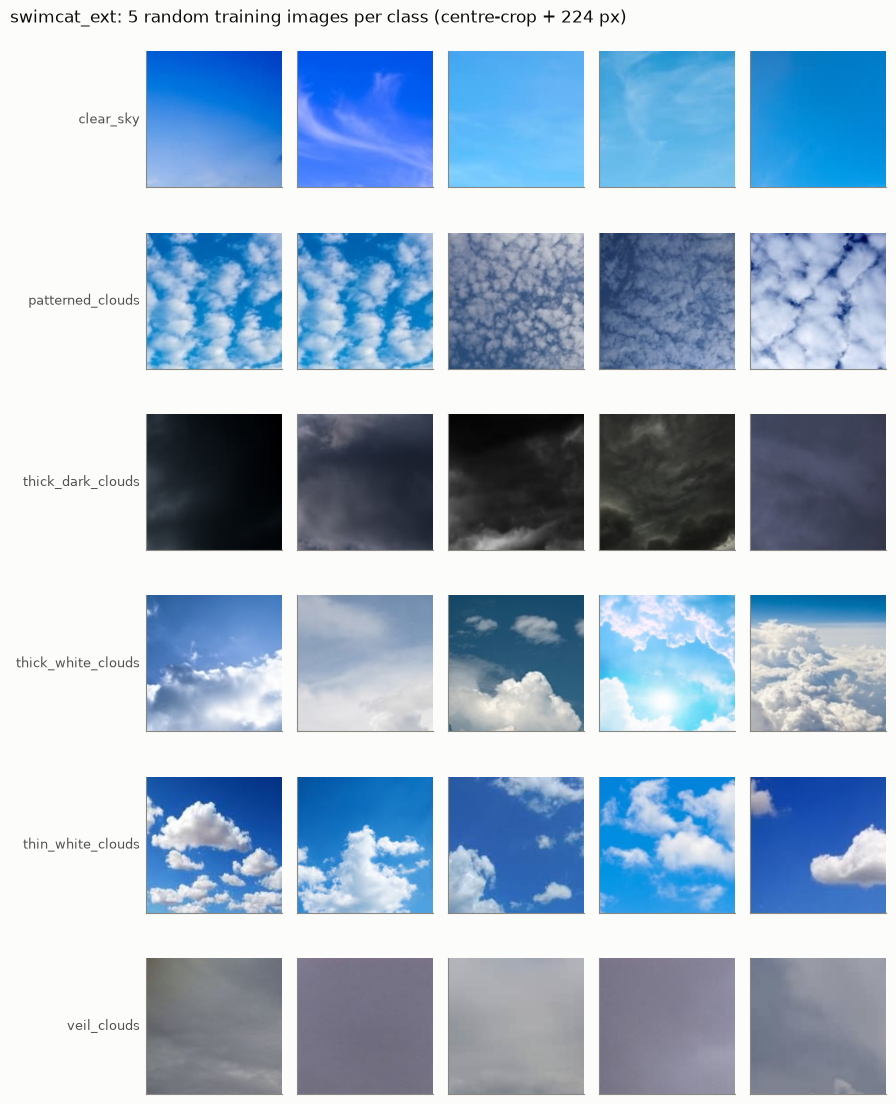

In [3]:
for n, t in tabs.items():
    train = t[t["split"] == "train"]
    labels = sorted(train["label"].unique())
    fig, axes = plt.subplots(len(labels), 5, figsize=(9, 1.9 * len(labels)))
    for r, lab in enumerate(labels):
        paths = train.loc[train["label"] == lab, "path"].sample(5, random_state=0)
        for c, p in enumerate(paths):
            ax = axes[r, c]
            ax.imshow(sd.load_image(sd.resolve(p)))
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            if c == 0:
                ax.set_ylabel(lab, rotation=0, ha="right", va="center", fontsize=9)
    fig.suptitle(f"{n}: 5 random training images per class (centre-crop + 224 px)", x=0.01, ha="left")
    fig.tight_layout()
    save(fig, f"sky_samples_{n}.png")

## 2. ตัวอย่าง augmentation (ใช้ตอนฝึกเท่านั้น)

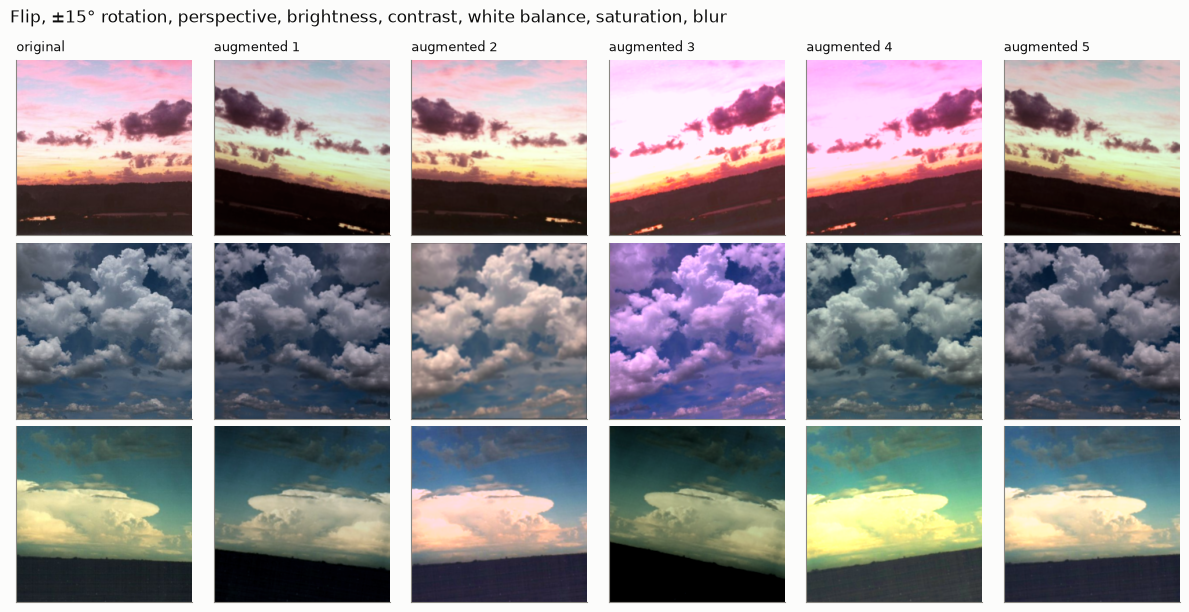

In [4]:
aug = sd.augmenter(seed=3)
t = tabs["ccsn"]
paths = t[t["split"] == "train"].sample(3, random_state=1)["path"].tolist()
x = np.stack([sd.load_image(sd.resolve(p)) for p in paths])
fig, axes = plt.subplots(3, 6, figsize=(12, 6.2))
for r in range(3):
    axes[r, 0].imshow(x[r]); axes[r, 0].set_title("original" if r == 0 else "", loc="left", fontsize=9)
    for c in range(1, 6):
        axes[r, c].imshow(np.asarray(aug(x[r : r + 1], training=True))[0])
        if r == 0:
            axes[r, c].set_title(f"augmented {c}", loc="left", fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Flip, ±15° rotation, perspective, brightness, contrast, white balance, saturation, blur",
             x=0.01, ha="left")
fig.tight_layout()
save(fig, "sky_augmentation.png")

## 3. ภาพเดียวกันที่อยู่คนละ label ใน CCSN (label conflict)

,groups
label,
Ns/St,20
Cc/Cs,12
Cb/Cu,10
Sc/St,10
Ac/Cc,8
Cs/Sc,6
Ns/Sc,6
As/Cb,4
As/Cs,4


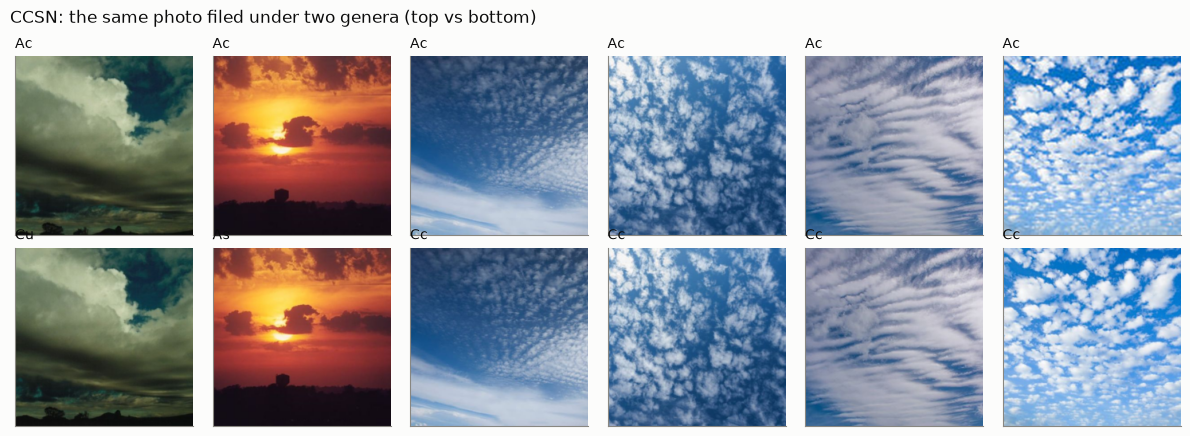

In [5]:
t = tabs["ccsn"]
conf = t[t["label_conflict"]]
pairs = conf.groupby("dup_group")["label"].apply(lambda s: "/".join(sorted(set(s)))).value_counts()
display(pairs.rename("groups").to_frame())
show = conf[conf["split"] == "train"]["dup_group"].drop_duplicates().head(6)
fig, axes = plt.subplots(2, 6, figsize=(12, 4.4))
for c, g in enumerate(show):
    rows = conf[conf["dup_group"] == g].head(2)
    for r, (p, lab) in enumerate(zip(rows["path"], rows["label"])):
        axes[r, c].imshow(sd.load_image(sd.resolve(p)))
        axes[r, c].set_title(lab, loc="left", fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("CCSN: the same photo filed under two genera (top vs bottom)", x=0.01, ha="left")
fig.tight_layout()
save(fig, "sky_ccsn_label_conflicts.png")

## สรุป

- **ดาวน์โหลดและตรวจ checksum แล้ว:** CCSN (CC0, 2,543 ภาพ, 11 ชนิด) และ SWIMCAT-ext (CC BY 4.0, 2,100 ภาพ, 6 คลาส × 350) ส่วน SWIMCAT/SWIMSEG (CC BY-NC) ยังรอลิงก์จากแบบฟอร์ม
- **Split (70/15/15, stratified, seed 42):**
  - CCSN: train 1,785 / val 383 / test 375
  - SWIMCAT-ext: train 1,472 / val 317 / test 311
  - ภาพที่ซ้ำหรือเกือบซ้ำ**อยู่ใน split เดียวกันทั้งหมด** (0 กลุ่มที่คร่อม split)
- **วิธีหาภาพซ้ำ:** ลอง dHash ก่อนแต่ใช้ไม่ได้ เพราะภาพที่ texture น้อยถูกโยงต่อกันเป็นกลุ่มละ ~50 ภาพที่ไม่เกี่ยวกัน และจับภาพที่หมุนไม่ได้ จึงเปลี่ยนเป็นเทียบ thumbnail 16×16 (ค่าต่างน้อยสุดจากการหมุน/พลิกทั้ง 8 แบบ < 0.03) threshold เลือกจากการดูคู่ภาพจริง
- **พบปัญหาคุณภาพข้อมูล:**
  - **CCSN มี 263 ภาพ (124 กลุ่ม) ที่เป็นรูปเดียวกันแต่อยู่คนละชนิดเมฆ** (มากสุดคือ Ns/St, Cc/Cs, Cb/Cu) ติด flag `label_conflict` ไว้ และ**เสนอให้ตัดทิ้งจากทุก split ในวัน 14** โดยประกาศก่อนฝึก
  - SWIMCAT-ext มี 1,470/2,100 ภาพอยู่ในกลุ่มซ้ำ (ขยายมาจาก SWIMCAT 784 ภาพ) และหลายภาพดูเหมือนภาพถ่ายทั่วไปจากเว็บ ไม่ใช่ patch จากกล้องท้องฟ้า (ข้อสังเกตจากการดูภาพ ยังไม่ได้ยืนยันแหล่งที่มา)
- **Preprocessing:** ครอปกลางแล้ว resize เป็น 224 **Augmentation** (ใช้ตอนฝึกเท่านั้น): flip, หมุน ±15°, perspective, ความสว่าง, contrast, white balance, saturation, blur
- test split อ่านได้เฉพาะเมื่อส่ง `confirm_test=True` (วัน 14 หลังประกาศเกณฑ์)